In [1]:
import numpy as np
import matplotlib.pyplot as plt
from fno_definitions import*
import torch

# Literature

1) FNO for differential equations
https://arxiv.org/abs/2010.08895

2) General introduction, complete
https://arxiv.org/abs/2512.01421v2, see NeuralOperator 2.0.0 library

# Minor stuff and trials

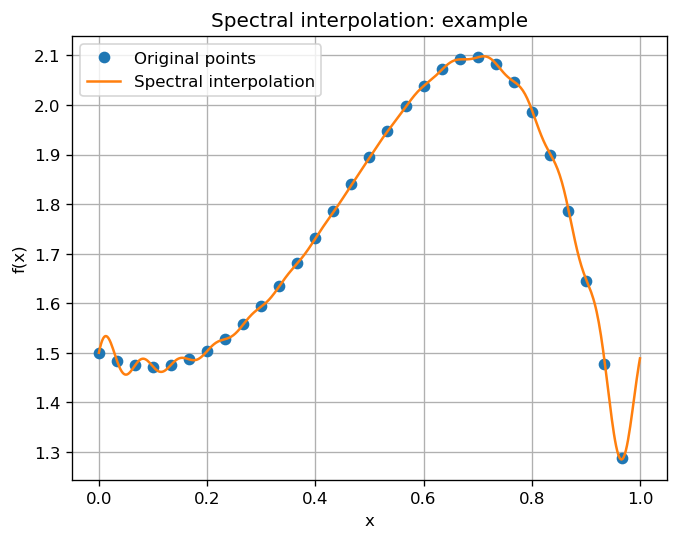

In [2]:
# test: spectral interpolation of 1d vector

def spectral_interpolation(signal: torch.tensor, M: int) -> torch.Tensor:

    """Gives the spectral interpolation of a 1d array on M points. Following 2), page 16"""
    N = len(signal) 
    fft_coeffs = torch.fft.fft(signal)
    pos_freqs = fft_coeffs[:N//2 + 1]
    neg_freqs = fft_coeffs[N//2 + 1:]

    fft_coeffs_padded = torch.cat([pos_freqs, torch.zeros(M - N), neg_freqs])

    return (torch.fft.ifft(fft_coeffs_padded).real)*M/N # the interpolated signal, scale by M/N to preserve energy


f = lambda x: torch.sin(3*x**2) + 0.5*torch.cos(torch.sqrt(x)) + 1.0 - x/3.

N = 30
xx = torch.linspace(0, 1, N+1)[:-1] # data x_n, n from 0 to N-1 

M_eval = 500

plt.figure(dpi = 120)
plt.title('Spectral interpolation: example')
plt.grid()
plt.xlabel('x')
plt.ylabel('f(х)')
plt.plot(xx, f(xx), 'o', label = 'Original points')
plt.plot(torch.linspace(0, 1, M_eval), spectral_interpolation(f(xx), M_eval), label = 'Spectral interpolation')
plt.legend()
plt.show()

In [4]:
# notes for later

from neuralop.models import FNO

operator = FNO(n_modes=(64, 64),
               hidden_channels=64,
               in_channels=2,
               out_channels=1)

# First FNO trial (with definition from `fno_definitions.py`)

In [2]:
# start with something reasonably small
fno_trial = FNO_v1(n_modes = [8,8], hidden_dimension = 24)

# note that compared to the way I set up the deepONets, here the X and Y (input and output) arrays are kept 2d and not flattened with .ravel().
# this is because I need to distinguish the two directions for the 2d fft to be applicable

# the solutions in the dataset are computed on the [-1, 1] 2d-square, on a 64x64 grid
fno_trial.fit_from_npz('data/dataset_for_fno.npz', 100)

Y std across samples: 0.04565034061670303
Y std across points:  0.02651088498532772
Epoch [10/100], Loss: 0.0099, Loss eval: 0.0084
prediction std across samples: 0.02045227214694023
prediction std across points: 5.842997613525469e-11
Epoch [20/100], Loss: 0.0032, Loss eval: 0.0039
prediction std across samples: 0.035558342933654785
prediction std across points: 4.5234777729108444e-11
Epoch [30/100], Loss: 0.0025, Loss eval: 0.0028
prediction std across samples: 0.019218191504478455
prediction std across points: 4.3509855440770906e-11
Epoch [40/100], Loss: 0.0025, Loss eval: 0.0029
prediction std across samples: 0.016212891787290573
prediction std across points: 4.3838755542369157e-11
Epoch [50/100], Loss: 0.0022, Loss eval: 0.0026
prediction std across samples: 0.021758325397968292
prediction std across points: 3.9219301417592334e-11
Epoch [60/100], Loss: 0.0022, Loss eval: 0.0027
prediction std across samples: 0.02504715509712696
prediction std across points: 3.4418197458752076e-11
E

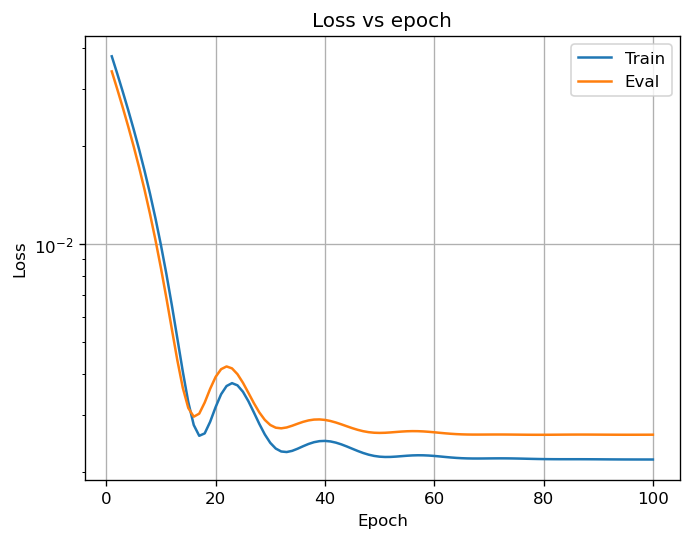

/var/folders/59/t4572hz13tg2y_6ql18g7cvw0000gn/T/ipykernel_14146/3426932002.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


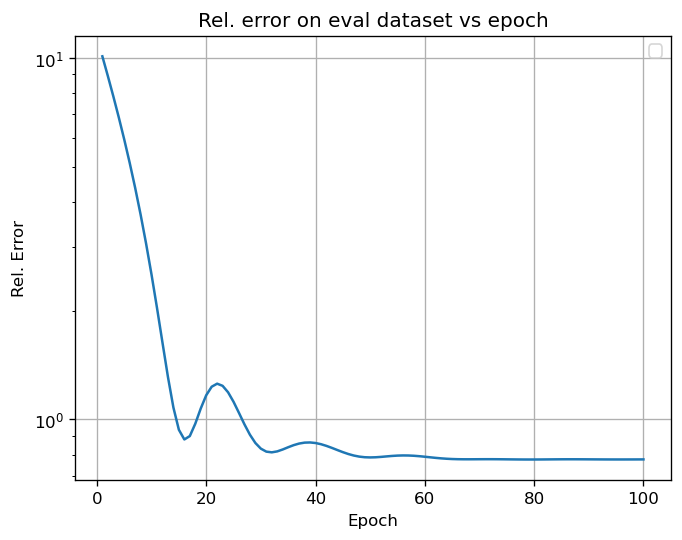

In [4]:
plt.figure(dpi = 120)
plt.title("Loss vs epoch")
plt.xlabel('Epoch')
plt.ylabel("Loss")
plt.semilogy(fno_trial.epochs, fno_trial.losses, label = "Train")
plt.semilogy(fno_trial.epochs, fno_trial.losses_eval, label = "Eval")
plt.legend()
plt.grid()
plt.show()

plt.figure(dpi = 120)
plt.title("Rel. error on eval dataset vs epoch")
plt.xlabel('Epoch')
plt.ylabel("Rel. Error")
plt.semilogy(fno_trial.epochs, fno_trial.rel_errors_eval)
plt.legend()
plt.grid()
plt.show()

In [ ]:
# the VERY low standard variation across points tell me the model gives some kind of constant function. this is a major issues that needs fixing
# also, the model is very slow and its speed should be improved. to do: use real fft, avoid fft shift